In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

   Feature_1  Feature_2  Feature_3  Feature_4
0  -0.638667   1.110057  -6.400722  -0.204990
1  -2.951556  -7.657445   3.844794   0.903589
2  -0.253177   2.125103  -7.869801   0.559678
3  -2.151209   3.401400  -5.734930   0.965230
4  -2.347519  -7.230467   3.478891  -0.443440
Original Shape: (500, 4)

PCA Data:
        PC1       PC2  True_Cluster
0  0.455305  1.623917             3
1 -2.705622  0.375012             1
2  0.810234  1.966926             3
3  0.427139  2.149626             3
4 -2.407508  0.099250             1

Explained Variance Ratio: [0.57208431 0.33622342]
Total Explained Variance: 0.908


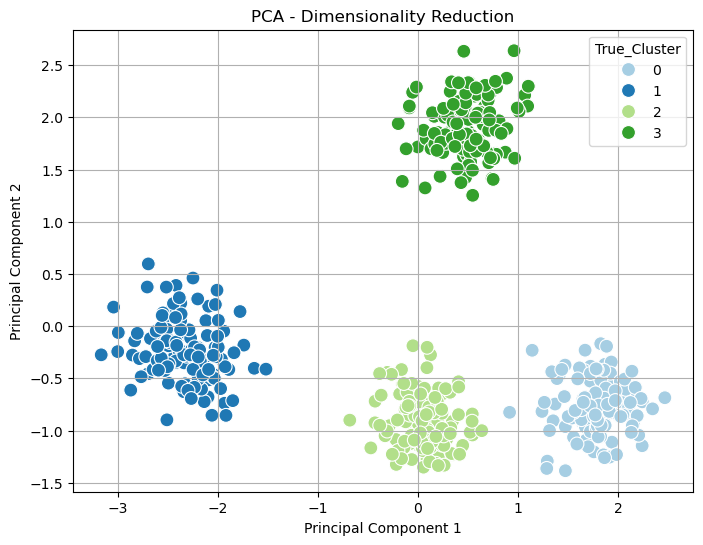

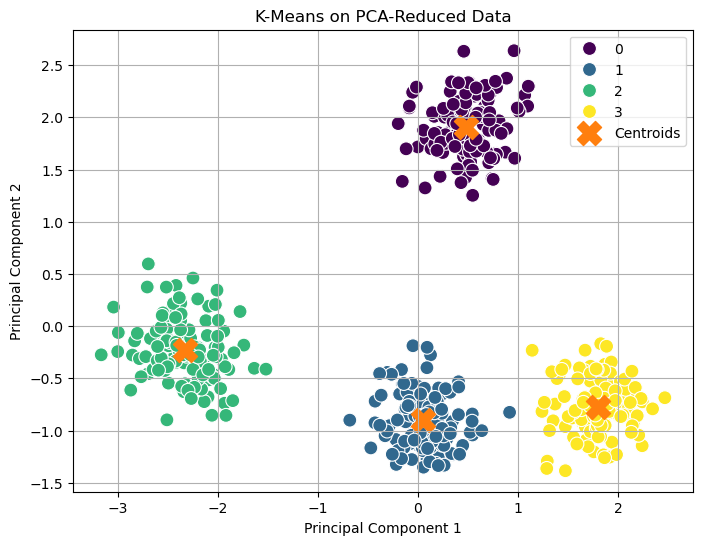

Silhouette Score: 0.776


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.0,
    random_state=25
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
)

print(df.head())
print("Original Shape:", df.shape)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["True_Cluster"] = y

print("\nPCA Data:")
print(df_pca.head())

variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:", variance)

print(
    "Total Explained Variance:",
    round(variance.sum(), 3)
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="True_Cluster",
    data=df_pca,
    palette="Paired",
    s=100
)

plt.title("PCA - Dimensionality Reduction")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

df_pca["KMeans_Cluster"] = clusters

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    data=df_pca,
    palette="viridis",
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("K-Means on PCA-Reduced Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

score = silhouette_score(X_pca, clusters)

print("Silhouette Score:", round(score, 3))